In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle


In [2]:
Myr_per_Nbody = 0.36627254517014160E+03/ 0.15200000000000000E+03
source = '/cosma5/data/durham/dc-pick2/simulations'
hyades = source + '/Hyades'
hyades

'/cosma5/data/durham/dc-pick2/simulations/Hyades'

In [3]:
path = hyades + '/snap.40_240.h5part'
path

'/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_240.h5part'

In [4]:
with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        mtot = np.sum(m)



In [5]:
def get_com(x, y, z, m):
    return [np.sum(m * axis) / np.sum(m) for axis in [x, y, z]]


def shrinking_sphere(x, y, z, m, r=100, rate=0.95, history=None, limit=1000):
    if rate >= 1: return

    count = 0
    
    guess = [np.median(axis)for axis in [x, y, z]]

    bound_x = x.copy()
    bound_y = y.copy()
    bound_z = z.copy()
    bound_m = m.copy()
    
    while True:
        if count > limit: 
            print('limit exceeded')
            return 
        
        if history is not None:
            history.append(guess)
        
        radii = np.sqrt( (bound_x - guess[0])**2 + (bound_y - guess[1])**2 + (bound_z - guess[2])**2 )
        
        idx = radii <= r

        if np.sum(idx) < 0.01 * len(x): return guess

        bound_x = bound_x[idx]
        bound_y = bound_y[idx]
        bound_z = bound_z[idx]
        bound_m = bound_m[idx]

        guess = get_com(bound_x, bound_y, bound_z, bound_m)

        r *= rate
        count += 1
        

    
    

In [6]:
get_com(x, y, z, m)

[np.float32(15.102393), np.float32(-7.5536737), np.float32(0.4713251)]

In [7]:
history = []
com = shrinking_sphere(x, y, z, m, history=history)

history = np.asarray(history)
history

array([[-1032.8811   ,   536.35803  ,    -9.94536  ],
       [-1033.0524   ,   535.5154   ,   -13.261286 ],
       [-1032.9248   ,   535.4217   ,   -13.173609 ],
       [-1032.9133   ,   535.31744  ,   -13.030437 ],
       [-1032.9125   ,   535.28235  ,   -12.581894 ],
       [-1033.1149   ,   535.39075  ,   -12.007958 ],
       [-1033.4073   ,   535.2103   ,   -11.395536 ],
       [-1033.3849   ,   535.27826  ,   -11.15978  ],
       [-1033.2651   ,   535.18256  ,   -10.943662 ],
       [-1033.2515   ,   535.1563   ,   -10.763935 ],
       [-1033.4396   ,   535.2703   ,   -10.513704 ],
       [-1033.6725   ,   535.47656  ,   -10.30563  ],
       [-1033.7566   ,   535.55634  ,   -10.127041 ],
       [-1033.7899   ,   535.5774   ,    -9.852741 ],
       [-1033.7423   ,   535.6365   ,    -9.715851 ],
       [-1033.604    ,   535.5576   ,    -9.61242  ],
       [-1033.5491   ,   535.6496   ,    -9.530256 ],
       [-1033.3627   ,   535.6416   ,    -9.426329 ],
       [-1033.3033   ,   535

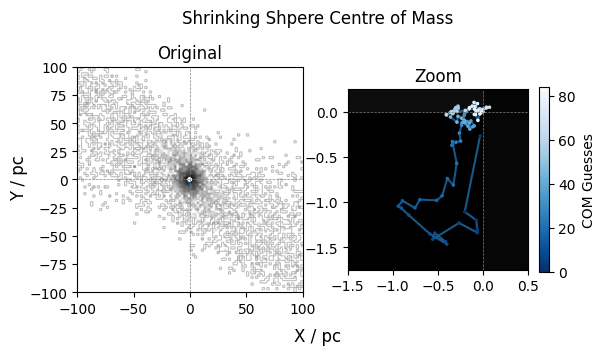

In [68]:
offset = 100
zoom_offset = 1

fig, ax = plt.subplots(1,2)

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[0].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)
hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[1].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)


histx = history.T[0]
histy = history.T[1]

ax[0].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75)
ax[1].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75)

ax[0].scatter(histx - com[0], histy - com[1], label='guesses', marker='.',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)
cb = ax[1].scatter(histx - com[0], histy - com[1], label='COM guesses', marker='.',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)

plt.colorbar(cb, ax=ax[1], shrink=0.5, label='COM Guesses')


ax[0].set_xlim(-offset, offset)
ax[0].set_ylim(- offset, offset)
ax[0].set_aspect('equal')
ax[0].set_title('Original')


ax[1].set_xlim(-zoom_offset-0.5, zoom_offset-0.5)
ax[1].set_ylim(- zoom_offset-0.75, zoom_offset-0.75)
ax[1].set_aspect('equal')
ax[1].set_title('Zoom')

ax[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[0].axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')

fig.supxlabel('X / pc', y=0.15)
fig.supylabel('Y / pc')

fig.suptitle('Shrinking Shpere Centre of Mass', y=0.85)

plt.savefig('Images/ShrinkShereCOM.png')
plt.show()

In [9]:
def find_bounding_radii(x, y, z, m, fractions):
    m_tot = np.sum(m)
    com = shrinking_sphere(x, y, z, m)

    radii = np.sqrt( (x - com[0])**2 + (y - com[1])**2 + (z - com[2])**2 )

    m_fractions = mtot * fractions

    idx = np.argsort(radii)
    radii_sort = radii[idx]
    m_sort = m[idx]
    
    m_cumul = np.cumsum(m_sort)
    
    frac_mass_radii = radii_sort[np.searchsorted(m_cumul, m_fractions)]
    return frac_mass_radii
    



In [10]:
fractions = np.asarray([0.75, 0.5, 0.25])
frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
frac_mass_radii

array([99.99002  , 28.555422 ,  7.4819603], dtype=float32)

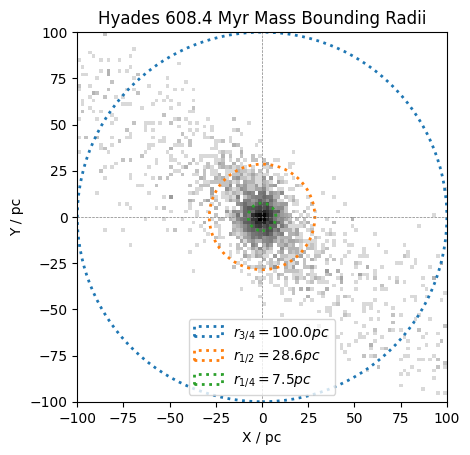

In [14]:
offset = 100
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}={v:.1f}pc$' for l, v in zip(frac_lables, frac_mass_radii)]
          
colours = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots()

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, 
                                      range=[[-offset, offset], [-offset, offset]])
ax.imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

for r, label, colour in zip(frac_mass_radii, lables, colours):
    r_mass_radius = Circle((0,0), r, fill=False, linestyle='dotted',
                           color=colour, label=label, linewidth=2)
    ax.add_artist(r_mass_radius)



ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title(f'Hyades {t:.1f} Myr Mass Bounding Radii')
ax.set_xlabel('X / pc')
ax.set_ylabel('Y / pc')
ax.set_xlim(-offset, offset)
ax.set_ylim(- offset, offset)
ax.set_aspect('equal')
plt.legend()

plt.show()


In [12]:
fractions = np.asarray([0.75, 0.5, 0.25])
results = []
times = []

for snap in [0, 60, 120, 180, 240]:
    path = hyades + f'/snap.40_{snap}.h5part'

    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
        results.append(frac_mass_radii)
        times.append(t)

    
results = np.asarray(results)
times = np.asarray(times)




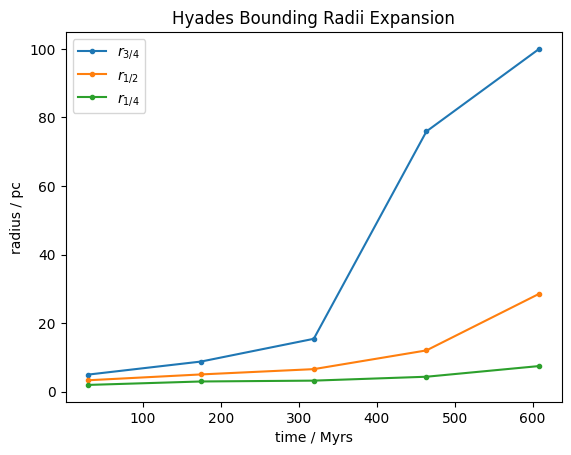

In [13]:
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}$' for l in frac_lables]

fig, ax = plt.subplots()

for i, (label, colour) in enumerate(zip(lables, colours)):
    ax.plot(times, results.T[i], label=label, color=colour, marker='.')

ax.set_xlabel('time / Myrs')
ax.set_ylabel('radius / pc')

#ax.set_yscale('log')

plt.title("Hyades Bounding Radii Expansion")
plt.legend()
plt.show()
 

In [14]:
results.T[0]

array([ 4.993082,  8.79833 , 15.429023, 75.92934 , 99.99002 ],
      dtype=float32)

In [15]:
def find_mass_profile(x, y, z, m):
    com = shrinking_sphere(x, y, z, m)

    radii = np.sqrt( (x - com[0])**2 + (y - com[1])**2 + (z - com[2])**2 )

    idx = np.argsort(radii)
    radii_sort = radii[idx]
    m_sort = m[idx]
    
    return radii_sort, m_sort, np.cumsum(m_sort)



In [16]:
fractions = np.asarray([0.75, 0.5, 0.25])
radiis = []
masses = []
times = []
sort_masses = []

for snap in [0, 60, 120, 180, 240]:
    path = hyades + f'/snap.40_{snap}.h5part'

    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        r_sort, m_sort, m_sums = find_mass_profile(x, y, z, m)
        masses.append(m_sums)
        sort_masses.append(m_sort)
        radiis.append(r_sort)
        times.append(t)

In [17]:
sort_masses[-1]

array([1.7703725, 1.8256862, 0.257332 , ..., 1.245391 , 1.440974 ,
       1.5798572], shape=(8460,), dtype=float32)

In [42]:
radiis[-1]


array([2.8335181e-01, 3.9118034e-01, 5.1766461e-01, ..., 2.5630205e+05,
       3.2457716e+05, 3.5732275e+05], shape=(8460,), dtype=float32)

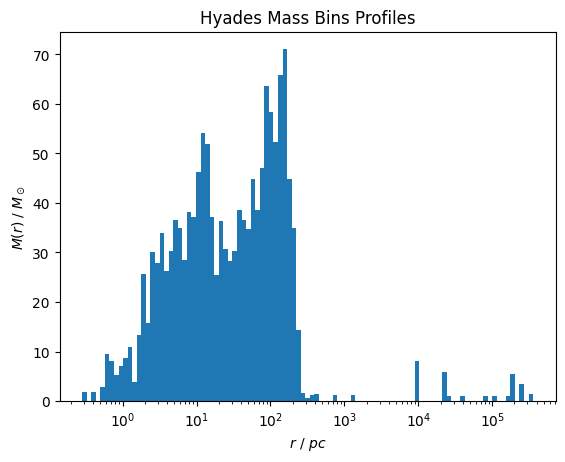

In [39]:
sort_r = radiis[-1]
sort_m = sort_masses[-1]


bins = np.logspace(np.log10(sort_r.min()), np.log10(sort_r.max()), 100)

plt.hist(sort_r, weights=sort_m, bins=bins)
plt.xscale('log')

plt.xlabel(r'$r$ / $pc$')
plt.ylabel(r'$M(r)$ / $M_\odot$')
plt.title('Hyades Mass Bins Profiles')

plt.show()

In [45]:
times

[np.float64(29.819886490003306),
 np.float64(174.70236529496887),
 np.float64(319.2836331252879),
 np.float64(463.86490095560697),
 np.float64(608.446168785926)]

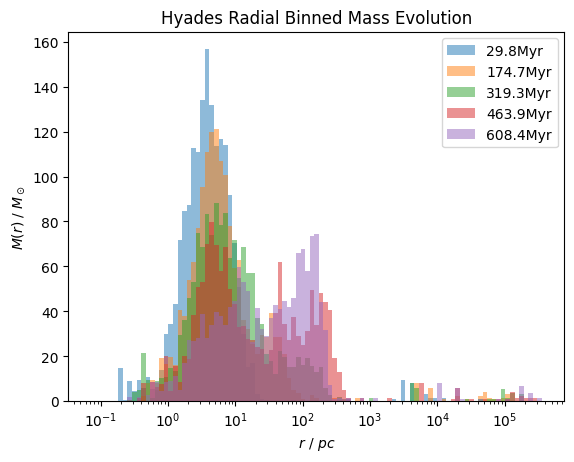

In [73]:
fig, ax = plt.subplots()

r_min = np.min(np.concatenate(radiis))
r_max = np.max( np.concatenate(radiis))

bins = np.logspace(np.log10(r_min), np.log10(r_max), 100)
for rs, w, t in zip(radiis, sort_masses, times):
    ax.hist(rs, weights=w, bins=bins, alpha=0.5, label=f'{t:.1f}Myr')

ax.set_xscale('log')

ax.set_xlabel(r'$r$ / $pc$')
ax.set_ylabel(r'$M(r)$ / $M_\odot$')

plt.title('Hyades Radial Binned Mass Evolution')
plt.legend()
plt.show()

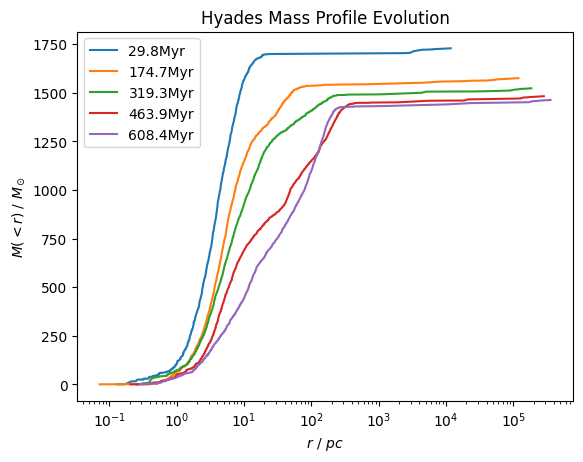

In [17]:
for r_sort, m_sums, t in zip(radiis, masses, times):
    plt.plot(r_sort, m_sums, label=f'{t:.1f}Myr')
    
plt.xscale('log')
#plt.yscale('log')

plt.legend()
plt.xlabel(r'$r$ / $pc$')
plt.ylabel(r'$M(<r)$ / $M_\odot$')
plt.title('Hyades Mass Profile Evolution')
plt.show()